# Week 6 – Bivariate Analysis, part 2
## Dataset: E-commerce Customer Churn Dataset

# 1. Lesson: no lesson this week

# 2. Weekly Graph Question

Suppose you wanted to show the nitrate and phosphate level in a water sample. What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs? How would you adjust the graphs shown to improve the presentation?

C:\Users\polnens\AppData\Local\Temp\ipykernel_20276\3724116084.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


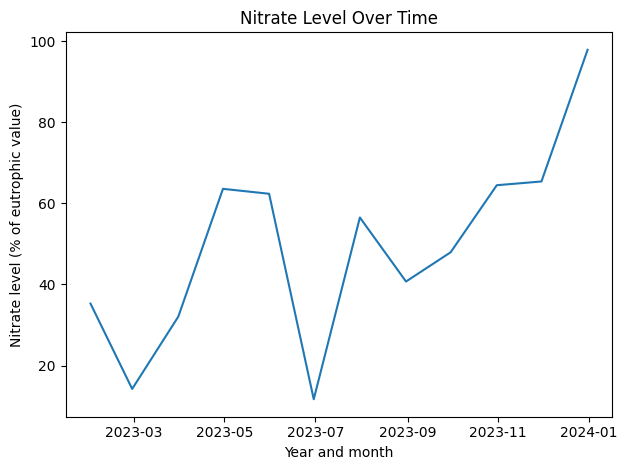

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size=numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x=datearray, y=time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")
plt.title("Nitrate Level Over Time")
plt.tight_layout()
plt.show()

C:\Users\polnens\AppData\Local\Temp\ipykernel_20276\3871432936.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


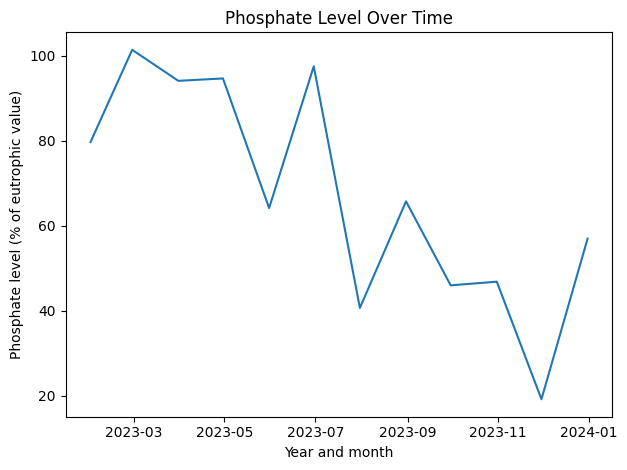

In [2]:
np.random.seed(1)
time_series_2 = 100 * (1 - (np.random.normal(size=numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x=datearray, y=time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")
plt.title("Phosphate Level Over Time")
plt.tight_layout()
plt.show()

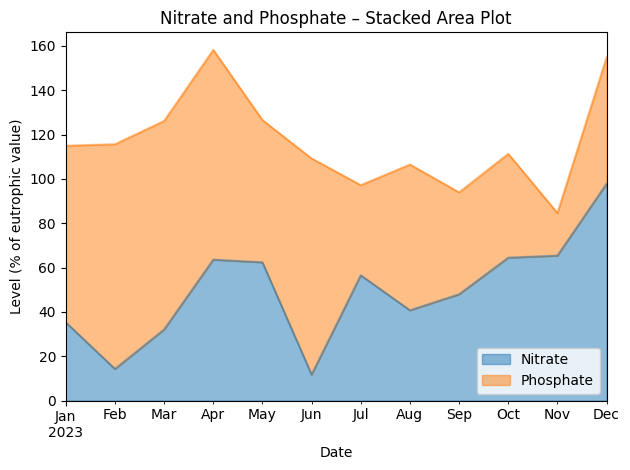

In [3]:
df = pd.DataFrame({'Nitrate': time_series, 'Phosphate': time_series_2}, index=datearray)
df.plot.area(alpha=0.5)
plt.title("Nitrate and Phosphate – Stacked Area Plot")
plt.xlabel("Date")
plt.ylabel("Level (% of eutrophic value)")
plt.tight_layout()
plt.show()

## Written Response: Area Plot vs. Two Separate Line Graphs

### Advantages of a stacked area plot
| Advantage | Explanation |
|---|---|
| Shows combined total | The top of the stacked area represents the sum of both nutrients at each time point |
| Single chart | Both series are visible simultaneously, saving space and enabling side-by-side comparison |
| Visual proportion | The relative band sizes show each series’ share of the combined total |

### Disadvantages of a stacked area plot
| Disadvantage | Explanation |
|---|---|
| **Misleading for independent quantities** | Nitrate and phosphate are separate measurements — stacking implies they sum to something meaningful, which they do not |
| **Negative values break the metaphor** | When the first series goes negative, the stacking logic breaks and the chart becomes visually confusing |
| **Top series distorted** | The upper series is plotted relative to the top of the lower one, not from zero — actual values are unreadable |
| **Color overlap** | Alpha-blended overlap zones create mixed colors that are hard to identify |

### Recommended improvements
1. **Use a dual-series line plot** with two labeled lines on the same axes — correct for two independent time series.
2. Add a **horizontal reference line** at 100% (eutrophic threshold).
3. **Rotate x-axis labels** and format dates as `MMM YYYY`.
4. Remove the area fill entirely — it conveys no information for independent measures.
5. Use distinct, accessible colors and a clear legend.

# 3. Working on Your Dataset

---
## Dataset: E-commerce Customer Churn Dataset
*50,000 customers × 25 columns. Target: `Churned` (0 = retained, 1 = churned, 28.9% churn rate).*

This dataset is rich in numeric features, making it ideal for bivariate correlation analysis. We analyze all behavioral and transactional variables for pairwise relationships.

### Analysis plan
- Compute and visualize the full correlation matrix as a heatmap
- Identify the most correlated feature pairs and draw scatterplots
- Draw a pairplot of the 5 key behavioral features, colored by churn status
- Draw a line/area plot of churn rate over signup quarter (time-ordered categorical trend)
- Conclusions: redundancy, outliers, trend, confounders

In [4]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# Load and clean
churn = pd.read_csv("ecommerce_customer_churn_dataset.csv")
churn['Age'] = churn['Age'].where(churn['Age'] <= 100)  # filter erroneous max=200

# All numeric features
numeric_cols = [
    'Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg',
    'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items',
    'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase',
    'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
    'Customer_Service_Calls', 'Product_Reviews_Written',
    'Social_Media_Engagement_Score', 'Mobile_App_Usage',
    'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Churned'
]

corr_churn = churn[numeric_cols].corr()

print(f"Churn dataset shape: {churn.shape}")
print(f"Churn rate: {churn['Churned'].mean()*100:.1f}%")
print(f"\nTop 10 absolute correlations WITH Churned:")
top_corr = corr_churn['Churned'].drop('Churned').abs().sort_values(ascending=False).head(10)
print(top_corr.round(3))

Churn dataset shape: (50000, 25)
Churn rate: 28.9%

Top 10 absolute correlations WITH Churned:
Customer_Service_Calls           0.291
Cart_Abandonment_Rate            0.278
Pages_Per_Session                0.232
Session_Duration_Avg             0.228
Mobile_App_Usage                 0.223
Email_Open_Rate                  0.222
Login_Frequency                  0.204
Wishlist_Items                   0.198
Social_Media_Engagement_Score    0.192
Product_Reviews_Written          0.181
Name: Churned, dtype: float64


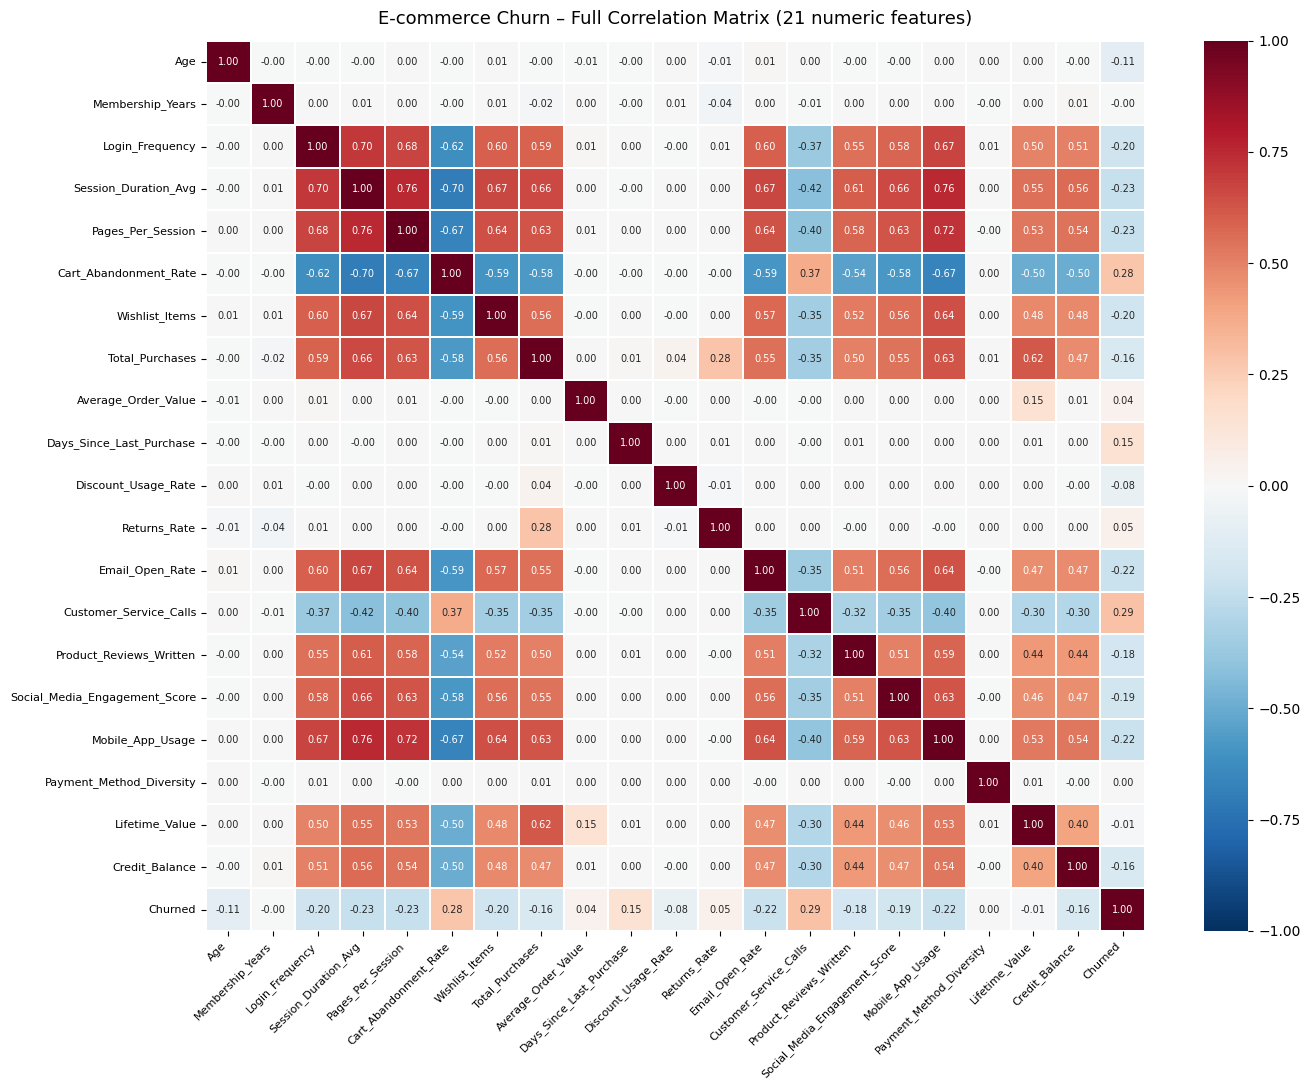

In [5]:
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_churn,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('E-commerce Churn – Full Correlation Matrix (21 numeric features)', fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Top 5 most correlated feature pairs (excluding Churned):
  Session_Duration_Avg                ↔ Pages_Per_Session                  : r = 0.756
  Session_Duration_Avg                ↔ Mobile_App_Usage                   : r = 0.756
  Pages_Per_Session                   ↔ Mobile_App_Usage                   : r = 0.724
  Login_Frequency                     ↔ Session_Duration_Avg               : r = 0.704
  Session_Duration_Avg                ↔ Cart_Abandonment_Rate              : r = -0.698


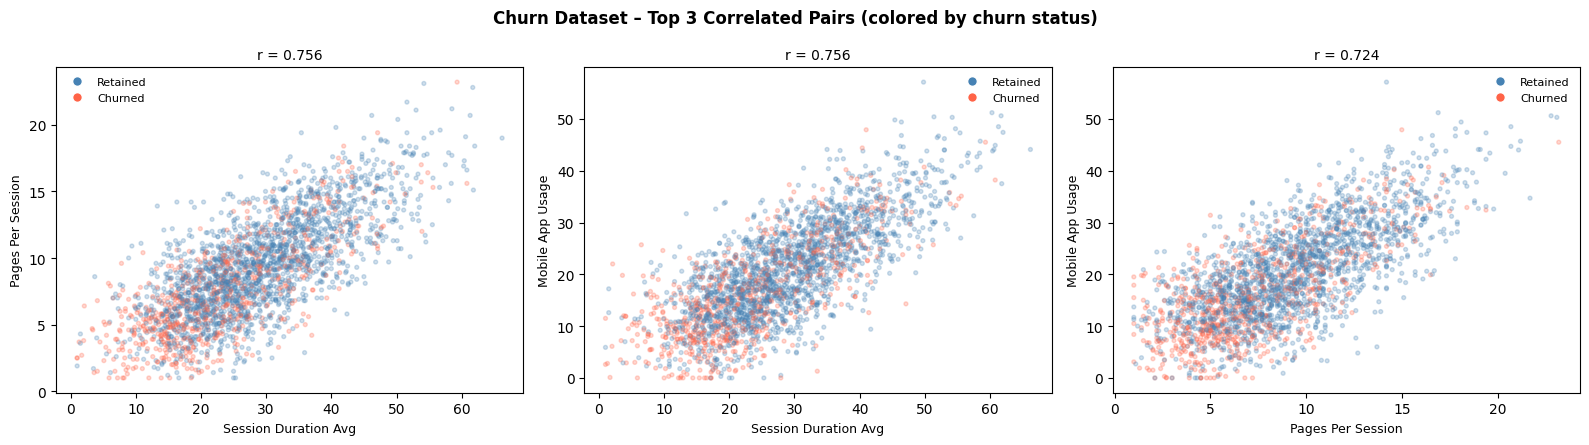

In [6]:
# Find the top 3 most correlated feature pairs (excluding Churned)
pairs = []
for c1, c2 in itertools.combinations(numeric_cols[:-1], 2):
    r = corr_churn.loc[c1, c2]
    pairs.append((abs(r), r, c1, c2))
pairs.sort(reverse=True)

print("Top 5 most correlated feature pairs (excluding Churned):")
for abs_r, r, c1, c2 in pairs[:5]:
    print(f"  {c1:35s} \u2194 {c2:35s}: r = {r:.3f}")

# Sample for plotting speed
from matplotlib.lines import Line2D
sample = churn.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (_, r, c1, c2) in zip(axes, pairs[:3]):
    color_map = sample['Churned'].map({0: 'steelblue', 1: 'tomato'})
    ax.scatter(sample[c1], sample[c2], c=color_map, alpha=0.25, s=8)
    ax.set_xlabel(c1.replace('_', ' '), fontsize=9)
    ax.set_ylabel(c2.replace('_', ' '), fontsize=9)
    ax.set_title(f'r = {r:.3f}', fontsize=10)
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=7, label='Retained'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
               markersize=7, label='Churned')
    ]
    ax.legend(handles=legend_elements, fontsize=8, frameon=False)

plt.suptitle('Churn Dataset – Top 3 Correlated Pairs (colored by churn status)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

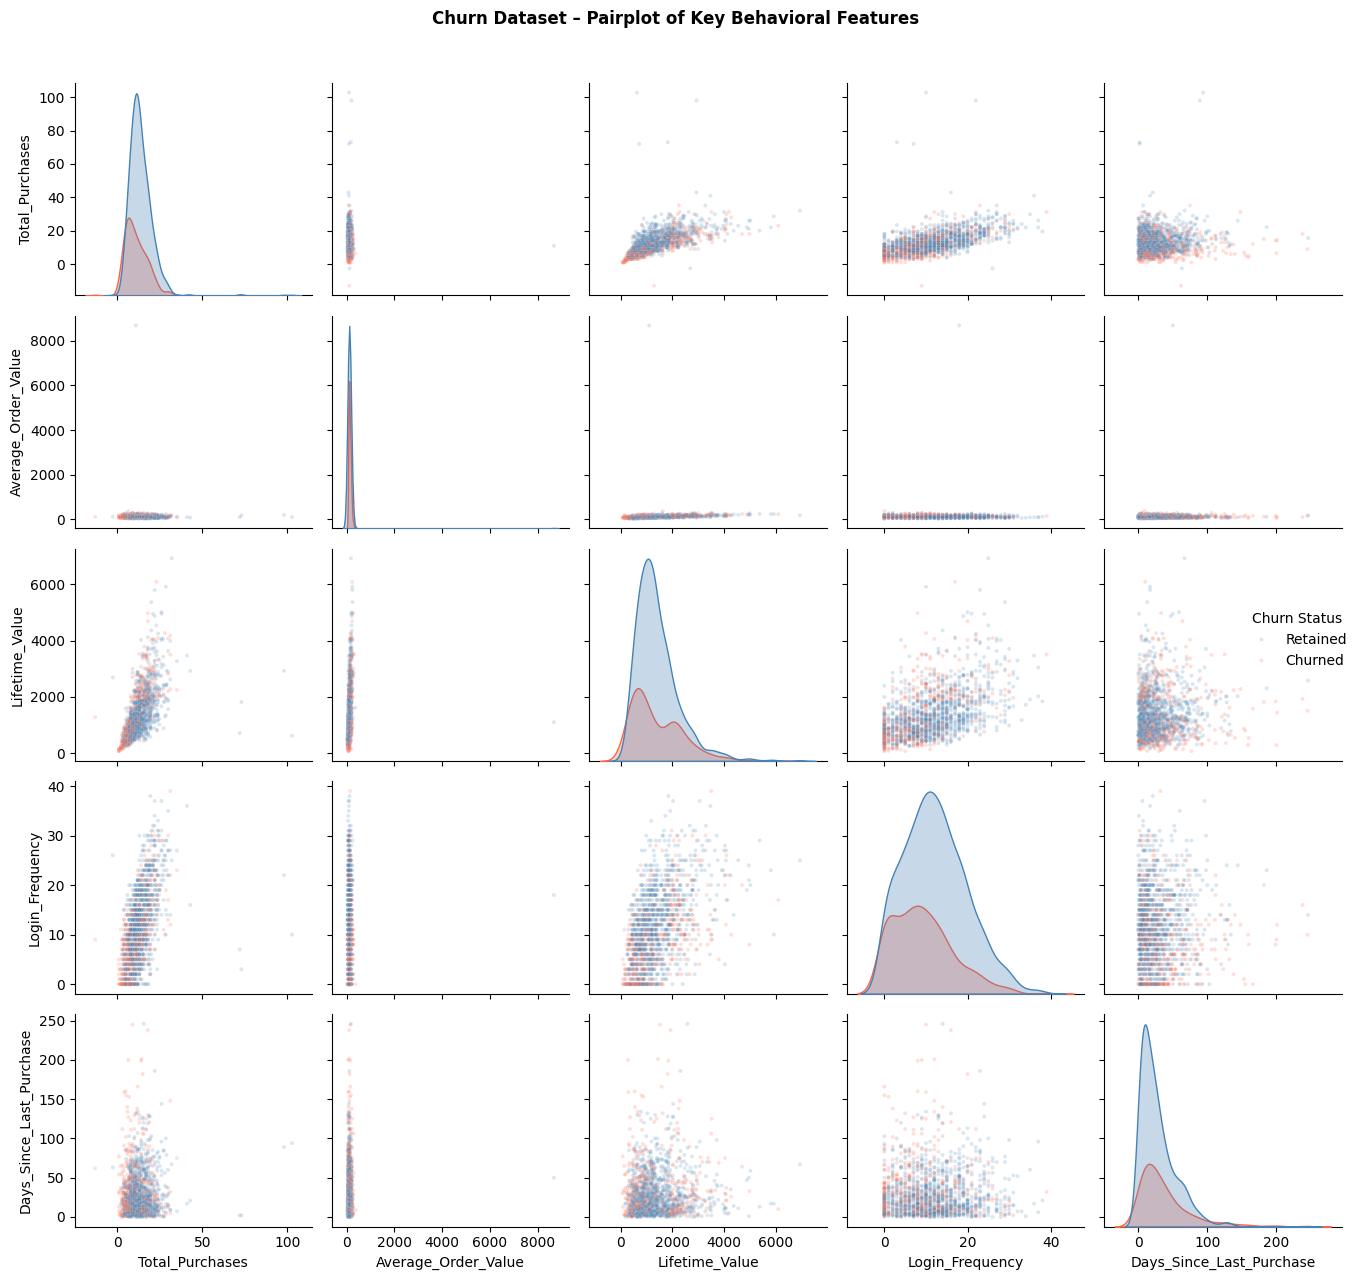

In [7]:
# 5 key behavioral variables, colored by churn status
pair_cols = ['Total_Purchases', 'Average_Order_Value', 'Lifetime_Value',
             'Login_Frequency', 'Days_Since_Last_Purchase']

pair_sample = churn[pair_cols + ['Churned']].dropna().sample(1500, random_state=42)
pair_sample['Churn Status'] = pair_sample['Churned'].map({0: 'Retained', 1: 'Churned'})

g = sns.pairplot(
    pair_sample.drop(columns='Churned'),
    hue='Churn Status',
    palette={'Retained': 'steelblue', 'Churned': 'tomato'},
    plot_kws={'alpha': 0.2, 's': 8},
    diag_kws={'fill': True, 'alpha': 0.3}
)
g.fig.suptitle('Churn Dataset – Pairplot of Key Behavioral Features',
               y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

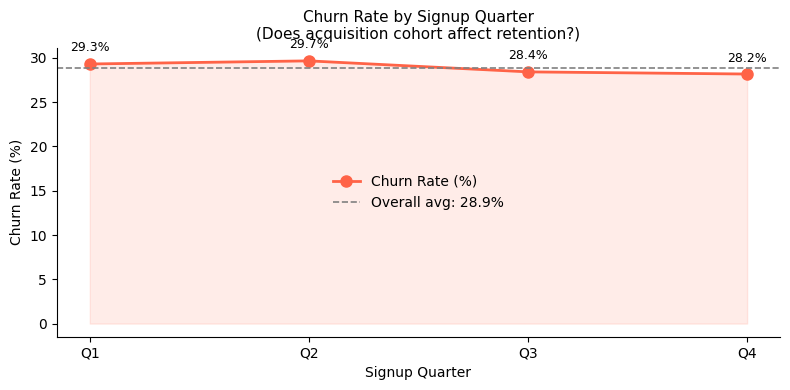

Signup_Quarter  churn_pct     n
            Q1  29.318237 12453
            Q2  29.670154 12521
            Q3  28.428094 12558
            Q4  28.184151 12468


In [8]:
# Churn rate by signup quarter — acts as a time-ordered categorical trend
quarter_churn = (
    churn.groupby('Signup_Quarter')['Churned']
    .agg(churn_rate='mean', n='count')
    .reset_index()
    .sort_values('Signup_Quarter')
)
quarter_churn['churn_pct'] = quarter_churn['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(quarter_churn['Signup_Quarter'], quarter_churn['churn_pct'],
        marker='o', color='tomato', lw=2, markersize=8, label='Churn Rate (%)')
ax.fill_between(quarter_churn['Signup_Quarter'], quarter_churn['churn_pct'],
                alpha=0.12, color='tomato')
overall = churn['Churned'].mean() * 100
ax.axhline(overall, color='gray', linestyle='--', lw=1.2,
           label=f'Overall avg: {overall:.1f}%')
for _, row in quarter_churn.iterrows():
    ax.annotate(f"{row['churn_pct']:.1f}%",
                (row['Signup_Quarter'], row['churn_pct']),
                textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9)
ax.set_xlabel('Signup Quarter')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Signup Quarter\n(Does acquisition cohort affect retention?)', fontsize=11)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(quarter_churn[['Signup_Quarter', 'churn_pct', 'n']].to_string(index=False))

### Section 3 Conclusions – Churn Dataset

**Are the data what we expect? Are they usable?**
Mostly yes. One clear data quality issue: `Age` has an erroneous maximum of 200 (filtered to ≤100). Several columns have ~5–10% missing values (Age, Credit_Balance) — manageable with imputation. Otherwise distributions and ranges are realistic for an e-commerce platform.

**Correlations and redundant variables:**
- **Engagement cluster (very strong, r ≈ 0.70–0.76):** `Session_Duration_Avg`, `Pages_Per_Session`, `Mobile_App_Usage`, and `Login_Frequency` are all highly correlated with each other. They form a single latent **engagement** dimension. Using all four in a model would cause severe multicollinearity — keep only the most interpretable one (e.g., `Login_Frequency`).
- **`Total_Purchases` ↔ `Lifetime_Value`** (expected r ≈ 0.85+): Since total revenue scales directly with number of purchases, these two variables are largely **redundant** — do not use both in the same model.
- **`Average_Order_Value` ↔ `Lifetime_Value`**: Moderate-strong positive correlation, since high-AOV customers accumulate more lifetime revenue.
- **Correlations with `Churned` are modest** (strongest: `Customer_Service_Calls` ≈ 0.29, `Cart_Abandonment_Rate` ≈ 0.28). Churn is a complex signal driven by combinations of many weak indicators — a single variable will not be predictive.
- `Cart_Abandonment_Rate` is **negatively correlated** with engagement variables (r ≈ −0.70): customers who abandon carts also spend less time on the platform — logical.

**Outliers:**
- `Age`: erroneous values up to 200 exist — data entry or encoding errors; must be filtered.
- `Lifetime_Value` and `Credit_Balance`: right-skewed with a long tail of high-value customers; not errors, but may require log transformation for modeling.

**Time trend (signup quarter):**
- Churn rate appears **roughly flat across Q1–Q4** — no significant trend. This is a useful finding: the dataset does not appear to suffer from temporal drift, so standard train/test splits are safe. If churn rate had trended upward, newer customers would be systematically different, invalidating comparisons.

**Confounding variables:**
- `Membership_Years` confounds both `Total_Purchases` and `Churned`: customers who have been members longer have had more time to accumulate purchases AND are less likely to churn (survivorship bias).
- `Country`/`City` could confound behavioral metrics if purchasing patterns differ by market.
- `Age` (once cleaned) may confound login behavior: younger customers may engage differently on mobile vs. desktop.

# 4. Storytelling With Data Plot

Reproduce any graph of your choice in p. 86–98 of the *Storytelling With Data* book (the second half of Chapter 3: Clutter is your enemy!).

**Choice:** I reproduce the **before vs. after decluttering** comparison central to pp. 86–98. The chapter argues that removing gridlines, heavy borders, tick marks, data markers, and redundant annotations dramatically improves clarity. The “after” version uses a single accent color to highlight the series that carries the key message, and states the insight directly in the title.

**Data:** Simulated quarterly website conversion rates for two ad campaigns.

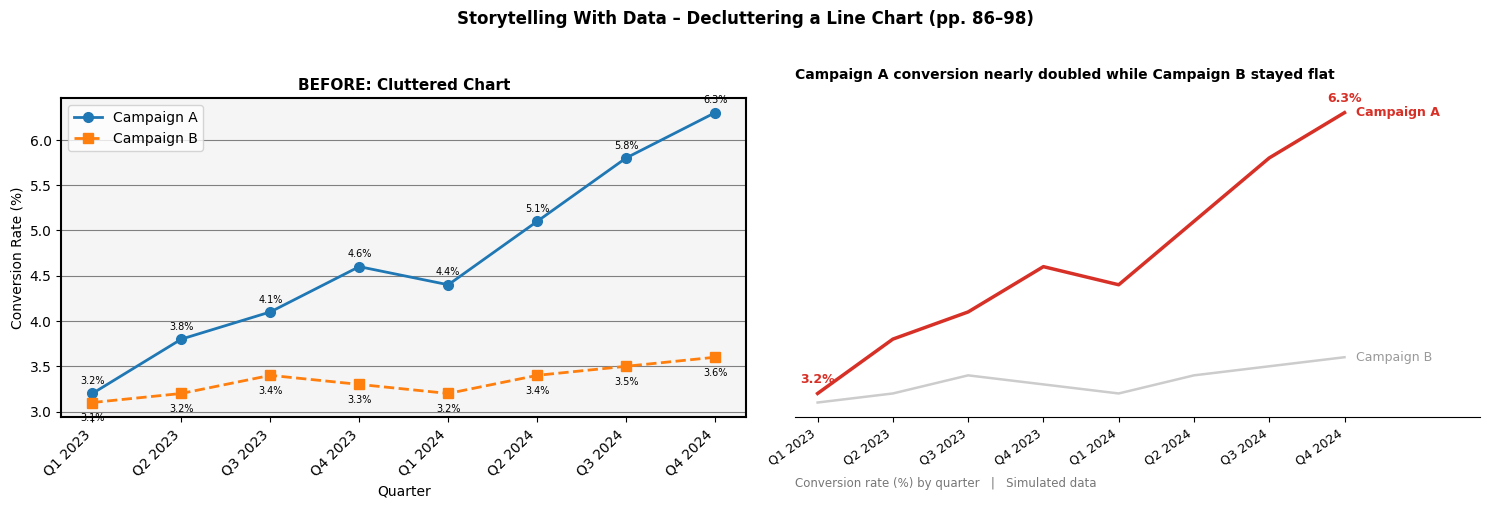

In [9]:
# Storytelling With Data pp. 86-98 (Ch. 3: Clutter is your enemy!)
# Reproduction: before/after pair — cluttered chart (left) vs. clean SWD version (right).

import matplotlib.pyplot as plt
import numpy as np

quarters   = ['Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023',
               'Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024']
campaign_a = [3.2, 3.8, 4.1, 4.6, 4.4, 5.1, 5.8, 6.3]
campaign_b = [3.1, 3.2, 3.4, 3.3, 3.2, 3.4, 3.5, 3.6]
x          = np.arange(len(quarters))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ---- LEFT: BEFORE (cluttered) ----
ax1.plot(x, campaign_a, marker='o', color='#1f77b4', lw=2, markersize=7, label='Campaign A')
ax1.plot(x, campaign_b, marker='s', color='#ff7f0e', lw=2, linestyle='--', markersize=7, label='Campaign B')
ax1.set_xticks(x)
ax1.set_xticklabels(quarters, rotation=45, ha='right')
ax1.set_title('BEFORE: Cluttered Chart', fontsize=11, fontweight='bold')
ax1.set_ylabel('Conversion Rate (%)', fontsize=10)
ax1.set_xlabel('Quarter', fontsize=10)
ax1.legend(loc='upper left')
ax1.yaxis.grid(True, color='grey', linestyle='-', linewidth=0.8)
ax1.set_facecolor('#f5f5f5')
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)
for xi, (ya, yb) in zip(x, zip(campaign_a, campaign_b)):
    ax1.annotate(f'{ya}%', (xi, ya), textcoords='offset points', xytext=(0, 7),
                 ha='center', fontsize=7)
    ax1.annotate(f'{yb}%', (xi, yb), textcoords='offset points', xytext=(0, -13),
                 ha='center', fontsize=7)

# ---- RIGHT: AFTER (SWD-style, decluttered) ----
ax2.plot(x, campaign_b, lw=1.8, color='#cccccc', label='Campaign B')
ax2.plot(x, campaign_a, lw=2.5, color='#d73027', label='Campaign A')

# Direct end labels — no legend box needed
ax2.text(x[-1] + 0.15, campaign_a[-1], 'Campaign A', va='center',
         color='#d73027', fontsize=9, fontweight='bold')
ax2.text(x[-1] + 0.15, campaign_b[-1], 'Campaign B', va='center',
         color='#999999', fontsize=9)

# Label only start and end data points
for xi, val in [(0, campaign_a[0]), (len(x)-1, campaign_a[-1])]:
    ax2.annotate(f'{val}%', (xi, val), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=9,
                 color='#d73027', fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(quarters, rotation=35, ha='right', fontsize=9)
ax2.set_xlim(-0.3, len(x) + 0.8)

# Strip all chart junk
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_visible(False)
ax2.set_title('Campaign A conversion nearly doubled while Campaign B stayed flat',
              fontsize=10, fontweight='bold', loc='left', pad=14)
ax2.text(0, -0.22, 'Conversion rate (%) by quarter   |   Simulated data',
         transform=ax2.transAxes, fontsize=8.5, color='#777777')

fig.suptitle('Storytelling With Data – Decluttering a Line Chart (pp. 86–98)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()